# **Classical Metrics Report**

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from IPython.display import display

# ─── Load the evaluation sample ───
data_path = 'evaluation_sample_n500.csv'

df = pd.read_csv(data_path)

# Create a combined identifier for model + prompt strategy
df['model_prompt_type'] = df['model'] + '_' + df['prompt_type']

# ─── Basic dataset overview ───
print("=" * 70)
print("DATASET LOADED")
print(f"→ Total records: {len(df):,}")
print(f"→ Unique models: {df['model'].nunique()}")
print(f"→ Unique prompt types: {df['prompt_type'].nunique()}")
print(f"→ Unique model+prompt combinations: {df['model_prompt_type'].nunique()}")
print("=" * 70)

print("\nColumns in the dataset:")
print("─" * 60)
for col in df.columns:
    dtype_str = str(df[col].dtype)
    n_unique = df[col].nunique()
    sample_vals = df[col].dropna().head(3).astype(str).tolist()
    print(f"{col: <38} | {dtype_str: <10} | {n_unique: >5} unique | sample: {sample_vals}")
print("─" * 60)

# Optional: quick peek at the first few rows (uncomment if needed)
# display(df.head(5))

print("\nReady for further analysis (statistical tests, classification metrics, post-hoc comparisons, etc.)")

DATASET LOADED
→ Total records: 500
→ Unique models: 5
→ Unique prompt types: 3
→ Unique model+prompt combinations: 15

Columns in the dataset:
────────────────────────────────────────────────────────────
source                                 | object     |     3 unique | sample: ['HellaSwag', 'ARC', 'MMLU']
item                                   | object     |   128 unique | sample: ['Context: He starts by filling in the receptacle with some tap water and closing the cap back on tight. then he\nOptions:\nA. puts the lid back on the tube and pulls even harder.\nB. puts some paste on the solution of the jar and rolls up the pucks before putting them back on.\nC. adds some soy sauce to the black bean sauce and cranks up the heat.\nD. takes the portable shower to his backyard where he shows the different attachments of the shower.', 'Question: In Nevada\'s Black Desert on October 15, 1997, Andy Green traveled a measured distance at an average speed of 339 meters per second in a jet-power

In [8]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from IPython.display import display


def calculate_overall_metrics(y_true, y_pred):
    """
    Compute and display overall classification metrics (accuracy, precision, recall, F1).
    Returns cleaned y_true, y_pred after removing NaN pairs.
    """
    # Remove rows where either true or predicted value is missing
    valid_mask = ~pd.isna(y_true) & ~pd.isna(y_pred)
    y_true_clean = y_true[valid_mask]
    y_pred_clean = y_pred[valid_mask]

    if len(y_true_clean) == 0:
        print("No valid (non-NaN) prediction pairs found.")
        return y_true_clean, y_pred_clean

    metrics = {
        "Accuracy":  round(accuracy_score(y_true_clean, y_pred_clean), 4),
        "Precision": round(precision_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0), 4),
        "Recall":    round(recall_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0), 4),
        "F1-Score":  round(f1_score(y_true_clean, y_pred_clean, average='weighted', zero_division=0), 4)
    }

    print("\n" + "═" * 60)
    print("🔹 Overall Classification Metrics (weighted average)")
    print("═" * 60)
    display(pd.DataFrame([metrics], index=["Value"]))

    return y_true_clean, y_pred_clean


def calculate_confusion_matrix(y_true, y_pred):
    """
    Compute and display the confusion matrix.
    Returns the sorted list of unique labels.
    """
    if len(y_true) == 0 or len(y_pred) == 0:
        print("No valid data to compute confusion matrix.")
        return []

    labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    print("\n" + "═" * 60)
    print("🔹 Confusion Matrix")
    print("═" * 60)
    display(cm_df)

    return labels


def calculate_group_metrics(df, group_column, answer_col='answer', model_answer_col='model_answer'):
    """
    Compute classification metrics aggregated by a grouping column (e.g. model, prompt_type).
    Displays a summary table.
    Returns the list of group names that had valid data.
    """
    print("\n" + "═" * 60)
    print(f"🔹 Aggregated Performance by {group_column.capitalize()}")
    print("═" * 60)

    group_metrics = []
    group_names = sorted(df[group_column].dropna().unique())

    for group_val in group_names:
        subset = df[df[group_column] == group_val]
        y_true = subset[answer_col].to_numpy()
        y_pred = subset[model_answer_col].to_numpy()

        valid = ~pd.isna(y_true) & ~pd.isna(y_pred)
        y_true = y_true[valid]
        y_pred = y_pred[valid]

        if len(y_true) == 0:
            continue

        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

        row = {
            group_column.capitalize(): group_val,
            "Accuracy":           round(report.get("accuracy", np.nan), 4),
            "Macro Precision":    round(report["macro avg"]["precision"], 4),
            "Macro Recall":       round(report["macro avg"]["recall"], 4),
            "Macro F1":           round(report["macro avg"]["f1-score"], 4),
            "Weighted Precision": round(report["weighted avg"]["precision"], 4),
            "Weighted Recall":    round(report["weighted avg"]["recall"], 4),
            "Weighted F1":        round(report["weighted avg"]["f1-score"], 4),
        }
        group_metrics.append(row)

    if not group_metrics:
        print("No groups with valid prediction pairs found.")
        return []

    summary_df = pd.DataFrame(group_metrics).set_index(group_column.capitalize())
    display(summary_df.round(4))

    return summary_df.index.tolist()


def calculate_f1_matrix(df, labels_all, group_names, group_column,
                        answer_col='answer', model_answer_col='model_answer'):
    """
    Build and display a matrix of per-class F1-scores across groups.
    Returns the F1 matrix (numpy array) and valid group names.
    """
    print("\n" + "═" * 60)
    print(f"🔹 Per-class F1-Score Matrix by {group_column.capitalize()}")
    print("═" * 60)

    f1_rows = []
    valid_groups = []

    for group_val in group_names:
        subset = df[df[group_column] == group_val]
        y_true = subset[answer_col].to_numpy()
        y_pred = subset[model_answer_col].to_numpy()

        valid = ~pd.isna(y_true) & ~pd.isna(y_pred)
        y_true = y_true[valid]
        y_pred = y_pred[valid]

        if len(y_true) == 0:
            continue

        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        valid_groups.append(group_val)

        row = []
        for label in labels_all:
            f1 = report.get(str(label), {}).get('f1-score', np.nan)
            row.append(round(f1, 4) if not np.isnan(f1) else np.nan)

        f1_rows.append(row)

    if not f1_rows:
        print("No valid data for any group.")
        return np.array([]), []

    f1_matrix = np.array(f1_rows).T   # shape: (n_classes, n_groups)
    df_f1 = pd.DataFrame(f1_matrix, index=labels_all, columns=valid_groups)

    display(df_f1.round(4))

    return f1_matrix, valid_groups


def perform_friedman_nemenyi(f1_matrix, group_names):
    """
    Perform Friedman test across groups on class-level F1 scores,
    followed by Nemenyi post-hoc test if significant.
    """
    if f1_matrix.size == 0 or f1_matrix.shape[1] < 3:
        print("Insufficient valid groups or data for Friedman test (need ≥ 3 groups).")
        return

    # Remove columns (groups) that contain any NaN
    valid_mask = ~np.isnan(f1_matrix).any(axis=0)
    f1_clean = f1_matrix[:, valid_mask]
    valid_groups = np.array(group_names)[valid_mask]

    if f1_clean.shape[1] < 3:
        print("Fewer than 3 groups remain after removing NaNs.")
        return

    print("\n" + "═" * 60)
    print("🔹 Friedman Test, Class-level F1 Scores across Groups")
    print("═" * 60)

    stat, p_value = stats.friedmanchisquare(*f1_clean.T)

    print(f"Statistic (χ²) = {stat:.3f}")
    print(f"p-value        = {p_value:.5f}")

    if p_value < 0.05:
        print("\nSignificant differences detected → running Nemenyi post-hoc test")
        print("Pairs with p < 0.05 indicate statistically significant difference")
        nemenyi_pvals = sp.posthoc_nemenyi_friedman(f1_clean)
        nemenyi_pvals.columns = valid_groups
        nemenyi_pvals.index = valid_groups
        display(nemenyi_pvals.round(5))
    else:
        print("\nNo significant differences (p ≥ 0.05) → skipping post-hoc test.")

In [9]:
# Analysis by prompt_type
answer_col = 'answer'
model_answer_col = 'model_answer'
group_type = 'prompt_type'

y_true = df[answer_col].to_numpy()
y_pred = df[model_answer_col].to_numpy()

valid = ~pd.isna(y_true) & ~pd.isna(y_pred)
y_true = y_true[valid]
y_pred = y_pred[valid]

calculate_overall_metrics(y_true, y_pred)
labels_all = calculate_confusion_matrix(y_true, y_pred)
group_names = calculate_group_metrics(df, group_type, answer_col, model_answer_col)
f1_scores, group_names = calculate_f1_matrix(df, labels_all, group_names, group_type, answer_col, model_answer_col)
perform_friedman_nemenyi(f1_scores, group_names)


════════════════════════════════════════════════════════════
🔹 Overall Classification Metrics (weighted average)
════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1-Score
Value,0.824,0.8578,0.824,0.8404



════════════════════════════════════════════════════════════
🔹 Confusion Matrix
════════════════════════════════════════════════════════════


,A,B,C,D,E
A,86,8,1,11,5
B,7,111,7,5,2
C,10,2,112,2,7
D,8,3,5,103,5
E,0,0,0,0,0



════════════════════════════════════════════════════════════
🔹 Aggregated Performance by Prompt_type
════════════════════════════════════════════════════════════


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
Prompt_type,,,,,,,
adversarial,0.7226,0.6455,0.5671,0.6035,0.8285,0.7226,0.7716
cot,0.8389,0.8403,0.8387,0.8384,0.8427,0.8389,0.8397
naive,0.8929,0.8928,0.8921,0.8923,0.8930,0.8929,0.8928



════════════════════════════════════════════════════════════
🔹 Per-class F1-Score Matrix by Prompt_type
════════════════════════════════════════════════════════════


,adversarial,cot,naive
A,0.5660,0.8101,0.8667
B,0.8732,0.8750,0.8571
C,0.8090,0.8308,0.9423
D,0.7692,0.8378,0.9032
E,0.0000,NaN,NaN


Fewer than 3 groups remain after removing NaNs.


In [10]:
# Analysis grouped by model
group_type = 'model'

# Prepare overall true and predicted values (across all models)
y_true = df[answer_col].to_numpy()
y_pred = df[model_answer_col].to_numpy()

# Remove rows with missing true or predicted values
valid_mask = ~pd.isna(y_true) & ~pd.isna(y_pred)
y_true = y_true[valid_mask]
y_pred = y_pred[valid_mask]

# Overall performance metrics (all models combined)
calculate_overall_metrics(y_true, y_pred)

# Confusion matrix (all models combined)
labels_all = calculate_confusion_matrix(y_true, y_pred)

# Per-model performance metrics
group_names = calculate_group_metrics(
    df,
    group_column=group_type,
    answer_col=answer_col,
    model_answer_col=model_answer_col
)

# Per-class F1-score matrix by model
f1_scores, group_names = calculate_f1_matrix(
    df,
    labels_all=labels_all,
    group_names=group_names,
    group_column=group_type,
    answer_col=answer_col,
    model_answer_col=model_answer_col
)

# Statistical test: Friedman + Nemenyi post-hoc (on per-class F1 scores across models)
perform_friedman_nemenyi(f1_scores, group_names)


════════════════════════════════════════════════════════════
🔹 Overall Classification Metrics (weighted average)
════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1-Score
Value,0.824,0.8578,0.824,0.8404



════════════════════════════════════════════════════════════
🔹 Confusion Matrix
════════════════════════════════════════════════════════════


,A,B,C,D,E
A,86,8,1,11,5
B,7,111,7,5,2
C,10,2,112,2,7
D,8,3,5,103,5
E,0,0,0,0,0



════════════════════════════════════════════════════════════
🔹 Aggregated Performance by Model
════════════════════════════════════════════════════════════


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
Model,,,,,,,
model_claude_35_haiku,0.8119,0.6376,0.6306,0.6338,0.8185,0.8119,0.8149
model_ds_v3,0.8200,0.7055,0.6560,0.6781,0.8841,0.8200,0.8489
model_gpt_41_nano,0.8687,0.7407,0.6896,0.7135,0.9252,0.8687,0.8950
model_gpt_4o_mini,0.7228,0.6059,0.5795,0.5880,0.7616,0.7228,0.7358
model_grok_3_mini_beta,0.8990,0.7355,0.7192,0.7262,0.9208,0.8990,0.9082



════════════════════════════════════════════════════════════
🔹 Per-class F1-Score Matrix by Model
════════════════════════════════════════════════════════════


,model_claude_35_haiku,model_ds_v3,model_gpt_41_nano,model_gpt_4o_mini,model_grok_3_mini_beta
A,0.6061,0.8333,0.9000,0.7000,0.8293
B,0.9032,0.8095,0.9200,0.7317,0.9180
C,0.8235,0.8727,0.9180,0.7692,0.9744
D,0.8364,0.8750,0.8293,0.7391,0.9091
E,0.0000,0.0000,0.0000,0.0000,0.0000



════════════════════════════════════════════════════════════
🔹 Friedman Test, Class-level F1 Scores across Groups
════════════════════════════════════════════════════════════
Statistic (χ²) = 10.000
p-value        = 0.04043

Significant differences detected → running Nemenyi post-hoc test
Pairs with p < 0.05 indicate statistically significant difference


,model_claude_35_haiku,model_ds_v3,model_gpt_41_nano,model_gpt_4o_mini,model_grok_3_mini_beta
model_claude_35_haiku,1.00000,0.93068,0.62766,0.93068,0.49732
model_ds_v3,0.93068,1.00000,0.97512,0.49732,0.93068
model_gpt_41_nano,0.62766,0.97512,1.00000,0.17960,0.99964
model_gpt_4o_mini,0.93068,0.49732,0.17960,1.00000,0.11523
model_grok_3_mini_beta,0.49732,0.93068,0.99964,0.11523,1.00000


In [11]:
# Analysis grouped by model + prompt combination
group_type = 'model_prompt_type'

# Prepare overall true and predicted values (across all model-prompt combinations)
y_true = df[answer_col].to_numpy()
y_pred = df[model_answer_col].to_numpy()

# Remove rows with missing true or predicted values
valid_mask = ~pd.isna(y_true) & ~pd.isna(y_pred)
y_true = y_true[valid_mask]
y_pred = y_pred[valid_mask]

# Overall performance metrics (all model-prompt combinations combined)
calculate_overall_metrics(y_true, y_pred)

# Confusion matrix (all model-prompt combinations combined)
labels_all = calculate_confusion_matrix(y_true, y_pred)

# Per model-prompt combination performance metrics
group_names = calculate_group_metrics(
    df,
    group_column=group_type,
    answer_col=answer_col,
    model_answer_col=model_answer_col
)

# Per-class F1-score matrix by model-prompt combination
f1_scores, group_names = calculate_f1_matrix(
    df,
    labels_all=labels_all,
    group_names=group_names,
    group_column=group_type,
    answer_col=answer_col,
    model_answer_col=model_answer_col
)

# Statistical test: Friedman + Nemenyi post-hoc 
# (on per-class F1 scores across model-prompt combinations)
perform_friedman_nemenyi(f1_scores, group_names)


════════════════════════════════════════════════════════════
🔹 Overall Classification Metrics (weighted average)
════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1-Score
Value,0.824,0.8578,0.824,0.8404



════════════════════════════════════════════════════════════
🔹 Confusion Matrix
════════════════════════════════════════════════════════════


,A,B,C,D,E
A,86,8,1,11,5
B,7,111,7,5,2
C,10,2,112,2,7
D,8,3,5,103,5
E,0,0,0,0,0



════════════════════════════════════════════════════════════
🔹 Aggregated Performance by Model_prompt_type
════════════════════════════════════════════════════════════


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
Model_prompt_type,,,,,,,
model_claude_35_haiku_adversarial,0.7353,0.5395,0.5629,0.5450,0.7496,0.7353,0.7367
model_claude_35_haiku_cot,0.7692,0.7452,0.7500,0.7453,0.7648,0.7692,0.7649
model_claude_35_haiku_naive,0.9024,0.9020,0.9020,0.9020,0.9024,0.9024,0.9024
model_ds_v3_adversarial,0.6071,0.6333,0.4816,0.5453,0.8274,0.6071,0.6975
model_ds_v3_cot,0.8235,0.8292,0.8191,0.8155,0.8328,0.8235,0.8193
model_ds_v3_naive,0.9737,0.9808,0.9750,0.9768,0.9757,0.9737,0.9735
model_gpt_41_nano_adversarial,0.7576,0.7318,0.5800,0.6450,0.9291,0.7576,0.8320
model_gpt_41_nano_cot,0.8947,0.9167,0.9000,0.8920,0.9123,0.8947,0.8864
model_gpt_41_nano_naive,0.9362,0.9405,0.9333,0.9359,0.9377,0.9362,0.9360



════════════════════════════════════════════════════════════
🔹 Per-class F1-Score Matrix by Model_prompt_type
════════════════════════════════════════════════════════════


,model_claude_35_haiku_adversarial,model_claude_35_haiku_cot,model_claude_35_haiku_naive,model_ds_v3_adversarial,model_ds_v3_cot,model_ds_v3_naive,model_gpt_41_nano_adversarial,model_gpt_41_nano_cot,model_gpt_41_nano_naive,model_gpt_4o_mini_adversarial,model_gpt_4o_mini_cot,model_gpt_4o_mini_naive,model_grok_3_mini_beta_adversarial,model_grok_3_mini_beta_cot,model_grok_3_mini_beta_naive
A,0.2222,0.6667,0.8333,0.6154,0.8571,1.0000,0.8000,0.9091,0.9474,0.5882,0.7619,0.7273,0.5000,0.8571,0.8696
B,0.9000,1.0000,0.8462,0.6667,0.7143,0.9474,0.8889,1.0000,0.9167,0.8000,0.8182,0.4444,1.0000,0.9000,0.8889
C,0.8333,0.5455,0.9286,0.7778,0.8333,0.9600,0.8696,0.9091,0.9630,0.7200,0.7692,0.8571,0.9091,1.0000,1.0000
D,0.7692,0.7692,1.0000,0.6667,0.8571,1.0000,0.6667,0.7500,0.9167,0.8235,0.8000,0.4444,0.8235,1.0000,0.9231
E,0.0000,NaN,NaN,0.0000,NaN,NaN,0.0000,NaN,NaN,0.0000,NaN,NaN,0.0000,NaN,NaN



════════════════════════════════════════════════════════════
🔹 Friedman Test, Class-level F1 Scores across Groups
════════════════════════════════════════════════════════════
Statistic (χ²) = 3.897
p-value        = 0.42006

No significant differences (p ≥ 0.05) → skipping post-hoc test.


Calculating bootstrapped Weighted F1-scores (1,000 iterations)...
This may take a few moments depending on dataset size.


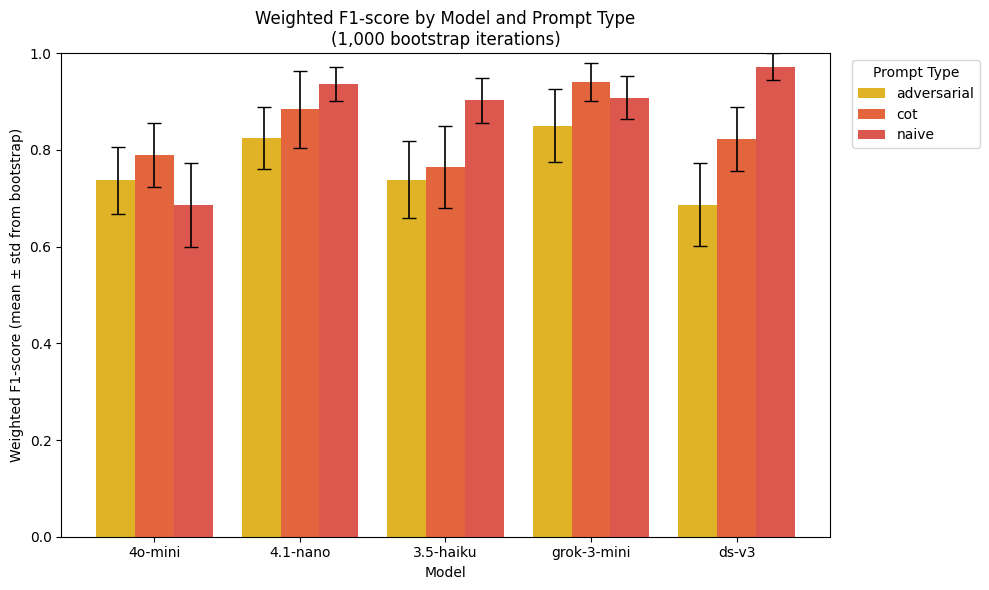


=== Summary of Weighted F1-scores (bootstrap estimates) ===



Mean     Std  Count
model       prompt                            
3.5-haiku   adversarial  0.7382  0.0794   1000
            cot          0.7653  0.0849   1000
            naive        0.9025  0.0468   1000
ds-v3       adversarial  0.6864  0.0856   1000
            cot          0.8227  0.0663   1000
            naive        0.9723  0.0281   1000
4.1-nano    adversarial  0.8252  0.0638   1000
            cot          0.8836  0.0793   1000
            naive        0.9369  0.0353   1000
4o-mini     adversarial  0.7367  0.0685   1000
            cot          0.7898  0.0667   1000
            naive        0.6859  0.0863   1000
grok-3-mini adversarial  0.8495  0.0754   1000
            cot          0.9400  0.0396   1000
            naive        0.9078  0.0447   1000

In [12]:
import seaborn as sns
from sklearn.utils import resample
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd


def calculate_bootstrapped_weighted_f1(
    df,
    model_col,
    prompt_col,
    answer_col,
    model_answer_col,
    n_iterations=1000
):
    """
    Calculate bootstrapped weighted F1-score for each model-prompt combination.
    
    Uses bootstrap resampling (with replacement) to estimate distribution
    of the weighted F1-score.
    """
    results = []
    
    for (model, prompt), group in df.groupby([model_col, prompt_col]):
        for _ in range(n_iterations):
            # Bootstrap sample (with replacement)
            sample = resample(group, replace=True, random_state=None)
            
            y_true = sample[answer_col].to_numpy()
            y_pred = sample[model_answer_col].to_numpy()
            
            # Remove invalid pairs (NaN in true or predicted)
            valid_mask = ~pd.isna(y_true) & ~pd.isna(y_pred)
            y_true = y_true[valid_mask]
            y_pred = y_pred[valid_mask]
            
            # Only compute score if we have valid data and more than one class
            if len(y_true) > 0 and len(np.unique(y_true)) > 1:
                score = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                results.append({
                    'model': model,
                    'prompt': prompt,
                    'weighted_f1': score
                })
    
    return pd.DataFrame(results)


def plot_bootstrapped_weighted_f1(f1_df, title="Weighted F1-score by Model and Prompt Type"):
    """
    Create a bar plot with mean bootstrapped weighted F1-scores,
    error bars showing standard deviation across bootstrap samples.
    """
    # Short, clean model names for visualization
    model_name_map = {
        "model_gpt_4o_mini":     "4o-mini",
        "model_gpt_41_nano":     "4.1-nano",
        "model_claude_35_haiku": "3.5-haiku",
        "model_grok_3_mini_beta": "grok-3-mini",
        "model_ds_v3":           "ds-v3"
    }
    
    # Clean and prepare data
    f1_df = f1_df.dropna()
    f1_df['model'] = f1_df['model'].map(model_name_map)
    
    # Compute mean and std per model-prompt combination
    summary_df = (
        f1_df.groupby(['model', 'prompt'], observed=True)
             .agg(mean_f1=('weighted_f1', 'mean'),
                  std_f1=('weighted_f1', 'std'))
             .reset_index()
    )
    
    # Define desired order for plotting
    model_order = ["4o-mini", "4.1-nano", "3.5-haiku", "grok-3-mini", "ds-v3"]
    prompt_order = ['adversarial', 'cot', 'naive']
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=summary_df,
        x='model',
        y='mean_f1',
        hue='prompt',
        order=model_order,
        hue_order=prompt_order,
        palette=['#FFC107', '#FF5722', '#F44336'],  # amber, deep-orange, red
        errorbar=None
    )
    
    # Add error bars (standard deviation from bootstrap)
    for i, row in summary_df.iterrows():
        if row['model'] in model_order and row['prompt'] in prompt_order:
            x_pos = (
                model_order.index(row['model']) +
                (prompt_order.index(row['prompt']) - 1) * 0.25
            )
            ax.errorbar(
                x=x_pos,
                y=row['mean_f1'],
                yerr=row['std_f1'],
                fmt='none',
                c='black',
                capsize=5,
                linewidth=1.2
            )
    
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel("Weighted F1-score (mean ± std from bootstrap)")
    plt.ylim(0, 1)
    plt.legend(title="Prompt Type", loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()


# ─── Execution ──────────────────────────────────────────────────────────────

print("Calculating bootstrapped Weighted F1-scores (1,000 iterations)...")
print("This may take a few moments depending on dataset size.")

f1_bootstrap_df = calculate_bootstrapped_weighted_f1(
    df,
    model_col='model',
    prompt_col='prompt_type',
    answer_col='answer',
    model_answer_col='model_answer',
    n_iterations=1000
)

# Plot the results
plot_bootstrapped_weighted_f1(
    f1_bootstrap_df,
    title="Weighted F1-score by Model and Prompt Type\n(1,000 bootstrap iterations)"
)

plt.savefig('figures/weighted_f1_scores_by_model_and_prompt_bootstrap.png', dpi=360)
plt.show()

# Summary table
print("\n=== Summary of Weighted F1-scores (bootstrap estimates) ===\n")
summary_table = (
    f1_bootstrap_df
    .groupby(['model', 'prompt'], observed=True)
    .agg(
        Mean=('weighted_f1', 'mean'),
        Std=('weighted_f1', 'std'),
        Count=('weighted_f1', 'count')
    )
    .round(4)
)

# Apply model name mapping to the summary table index for better readability
summary_table = summary_table.reset_index()
summary_table['model'] = summary_table['model'].map({
    "model_gpt_4o_mini":     "4o-mini",
    "model_gpt_41_nano":     "4.1-nano",
    "model_claude_35_haiku": "3.5-haiku",
    "model_grok_3_mini_beta": "grok-3-mini",
    "model_ds_v3":           "ds-v3"
})
summary_table = summary_table.set_index(['model', 'prompt'])

display(summary_table)